In [9]:
import sys
!{sys.executable} -m pip install spacy matplotlib scikit-learn pandas
!{sys.executable} -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
  Using cached spacy-3.8.15-cp313-cp313-win_amd64.whl.metadata (28 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp313-cp313-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp313-cp313-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp313-cp313-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp313-cp313-win_amd64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Jav_R\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------- -------------------------------- 2.4/12.8 MB 11.2 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.8 MB 11.6 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 11.6 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 11.7 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 11.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 11.4 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Jav_R\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Procesando pipeline... (esto puede tardar unos minutos)


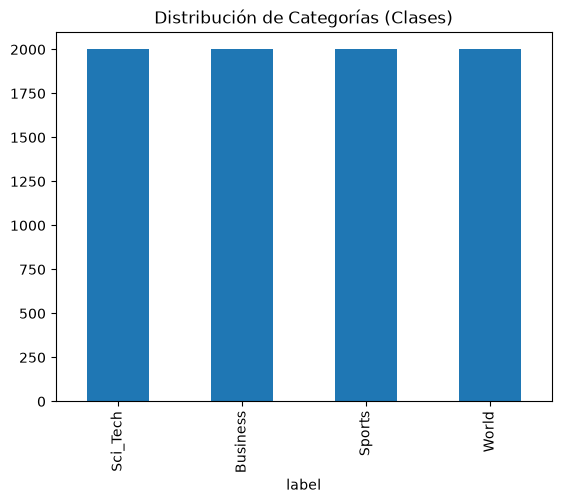

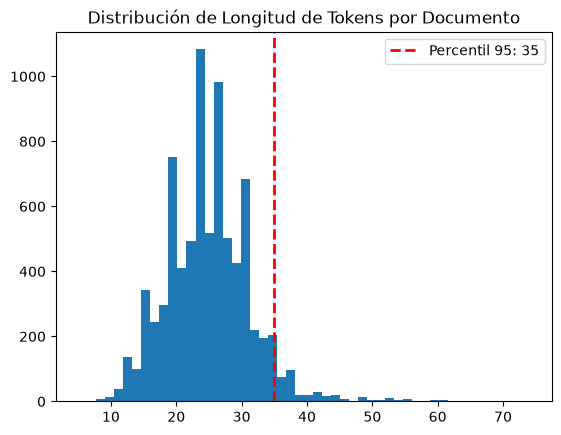

Top 20 Bi-gramas:
[('ap ap', np.int64(529)), ('new york', np.int64(419)), ('oil price', np.int64(197)), ('united states', np.int64(166)), ('york reuters', np.int64(158)), ('prime minister', np.int64(139)), ('afp afp', np.int64(134)), ('reuters reuters', np.int64(130)), ('official say', np.int64(115)), ('world 39', np.int64(103)), ('say thursday', np.int64(102)), ('say monday', np.int64(101)), ('say tuesday', np.int64(98)), ('red sox', np.int64(98)), ('san francisco', np.int64(96)), ('los angeles', np.int64(96)), ('president bush', np.int64(93)), ('say wednesday', np.int64(90)), ('say friday', np.int64(88)), ('year old', np.int64(88))]

Top 20 Tri-gramas:
[('new york reuters', np.int64(158)), ('quote profile research', np.int64(69)), ('world 39 large', np.int64(37)), ('boston red sox', np.int64(37)), ('york reuters stock', np.int64(31)), ('high oil price', np.int64(27)), ('canadian press canadian', np.int64(26)), ('press canadian press', np.int64(26)), ('prime minister ariel', np.int64(

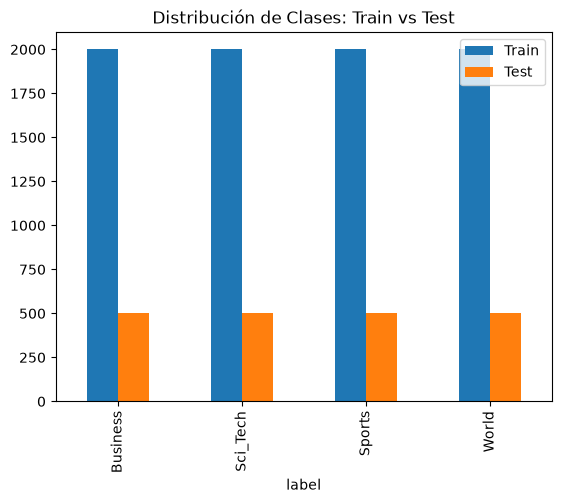

In [1]:
import pandas as pd
import re
import spacy
import html
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# 1. Cargar el modelo en INGLÉS
nlp = spacy.load("en_core_web_sm")

# 2. Función integradora del Pipeline
def preprocess_text(text: str) -> str:
    # 1. Decodificar entidades HTML (Convierte &lt; en <, y &#39; en apostrofes)
    text = html.unescape(str(text))
    
    # 2. Limpieza agresiva de ruido estructural y atributos web huérfanos
    text = re.sub(r'<[^>]+>', ' ', text) # Quitar tags completos
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Filtro específico para las palabras basura que detectó nuestro EDA:
    text = re.sub(r'\b(href|target|font|face|size|color|align|lt|gt|quickinfo|fullquote)\b', ' ', text, flags=re.IGNORECASE)
    
    text = re.sub(r'\s+', ' ', text).strip().lower()
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_stop]
    return " ".join(tokens)

# 3. Cargar el dataset ag_news_train.csv

df = pd.read_csv('../data/ag_news_train.csv')

# Para el EDA 
df_sample = df.copy()

print("Procesando pipeline... (esto puede tardar unos minutos)")
df_sample['text_clean'] = df_sample['text'].apply(preprocess_text)

# 4. EDA: Distribución de Clases
class_counts = df_sample['label'].value_counts()
class_counts.plot(kind='bar', title='Distribución de Categorías (Clases)')
plt.show()

# 5. EDA: Longitud de tokens e Histograma
df_sample['token_count'] = df_sample['text_clean'].apply(lambda x: len(x.split()))
p95 = np.percentile(df_sample['token_count'], 95)

plt.hist(df_sample['token_count'], bins=50)
plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label=f'Percentil 95: {p95:.0f}')
plt.title('Distribución de Longitud de Tokens por Documento')
plt.legend()
plt.show()

# 6. EDA: N-gramas con scikit-learn
def get_top_ngrams(corpus, n=None, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

print("Top 20 Bi-gramas:")
print(get_top_ngrams(df_sample['text_clean'], n=20, ngram_range=(2,2)))

print("\nTop 20 Tri-gramas:")
print(get_top_ngrams(df_sample['text_clean'], n=20, ngram_range=(3,3)))

print("Calculando el Top 50 de palabras en el texto crudo...")

# Unimos todo el texto CRUDO (la columna original 'text', sin limpiar) 
texto_crudo = " ".join(df_sample['text'].str.lower()).split()

# Extraemos el Top 50 absoluto
top_50_crudo = Counter(texto_crudo).most_common(50)

# Verificamos cuántas de esas 50 pertenecen a la lista de Stop-Words de SpaCy
stop_words_spacy = nlp.Defaults.stop_words
cantidad_stop_words = sum(1 for palabra, frec in top_50_crudo if palabra in stop_words_spacy)

print(f"\nDe las 50 palabras más frecuentes, {cantidad_stop_words} son Stop-Words.")
print("-" * 50)
print("Top 50 Palabras (Frecuencia | ¿Es Stop-Word?):")

# Armamos una tablita linda con Pandas para copiar al PDF
df_top50 = pd.DataFrame(top_50_crudo, columns=['Palabra', 'Frecuencia'])
df_top50['Es_StopWord'] = df_top50['Palabra'].apply(lambda x: 'Sí' if x in stop_words_spacy else 'No')
print(df_top50.to_string(index=False))

# Cargar ambos datasets, dataset train cargado antes en df

df_test = pd.read_csv('../data/ag_news_test.csv')

# Graficar balance (Train)
train_counts = df['label'].value_counts().sort_index()
print("Balance en Train:\n", train_counts)

# Graficar balance (Test)
test_counts = df_test['label'].value_counts().sort_index()
print("\nBalance en Test:\n", test_counts)

# Visualización conjunta opcional
pd.DataFrame({'Train': train_counts, 'Test': test_counts}).plot(
    kind='bar', title='Distribución de Clases: Train vs Test'
)
plt.show()